# 01 - Exploratory Data Analysis

UnderSure.AI: Machine Learning for Motor Insurance Risk Assessment

This notebook looks at the raw policy dataset (37.5k motor insurance
records) before any feature engineering or modeling.

Dataset columns: `ID`, `BirthDate`, `Car Color`, `Car Make`, `Car Model`,
`Car Use`, `Car Year`, `Coverage Zone`, `Education`, `Gender`,
`Marital Status`, `Parent`, `Claim Amount`, `Claim Freq`,
`Household Income`, `Kids Driving`.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from src.data_prep import load_raw_data, clean_data

raw = load_raw_data()
print(f"Raw shape: {raw.shape}")
raw.head()


Raw shape: (37542, 16)


,ID,BirthDate,Car Color,Car Make,Car Model,Car Use,Car Year,Coverage Zone,Education,Gender,Marital Status,Parent,Claim Amount,Claim Freq,Household Income,Kids Driving
0,62-2999778,1965-08-09,Green,Acura,TSX,Private,2017,Highly Urban,High School,Male,Single,Yes,7375.988,1,220436.66,2
1,70-2426103,1991-04-21,Turquoise,Corbin,Sparrow,Private,2011,Urban,Bachelors,Female,Married,No,7897.541,1,66491.43,0
2,08-3808219,2002-03-08,Orange,Nissan,Pathfinder,Private,2000,Rural,Bachelors,Male,Divorced,No,3090.401,0,56122.70,0
3,38-0306843,1962-05-10,Pink,Ford,Econoline E350,Private,2007,Highly Urban,Bachelors,Female,Single,No,3025.782,1,175182.61,0
4,47-5163637,1995-01-15,Green,Nissan,350Z,Commercial,2013,Rural,Masters,Male,Single,No,5043.402,3,137110.23,0


In [3]:
df = clean_data(raw)
print(f"After cleaning: {df.shape}")
df.describe(include='all').T


[data_prep] Dropped 1 duplicate policy rows.
After cleaning: (37530, 16)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,37530,37530,01-2964308,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BirthDate,37530,NaN,NaN,NaN,1979-05-06 17:20:52.949640256,1952-10-21 00:00:00,1966-01-25 00:00:00,1979-04-20 12:00:00,1992-07-26 00:00:00,2005-10-18 00:00:00,NaN
Car_Color,37530,19,Turquoise,2078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Make,37530,78,Ford,3295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Model,37530,1010,Grand Prix,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Use,37530,2,Private,30049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Car_Year,37530.0,NaN,NaN,NaN,2007.318039,1955.0,2002.0,2009.0,2014.0,2020.0,8.927621
Coverage_Zone,37530,5,Urban,7587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,37530,4,Bachelors,18697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,37530,2,Female,18799,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing values and data quality

In [4]:
df.isna().sum()

ID                  0
BirthDate           0
Car_Color           0
Car_Make            0
Car_Model           0
Car_Use             0
Car_Year            0
Coverage_Zone       0
Education           0
Gender              0
Marital_Status      0
Parent              0
Claim_Amount        0
Claim_Freq          0
Household_Income    0
Kids_Driving        0
dtype: int64

## Figures

The figures below come from `src/eda.py` (run once via `python -m src.eda`)
and are saved to `reports/figures/`. Displaying them here inline keeps the
notebook readable; regenerate them any time the data or risk-labeling
rules change.


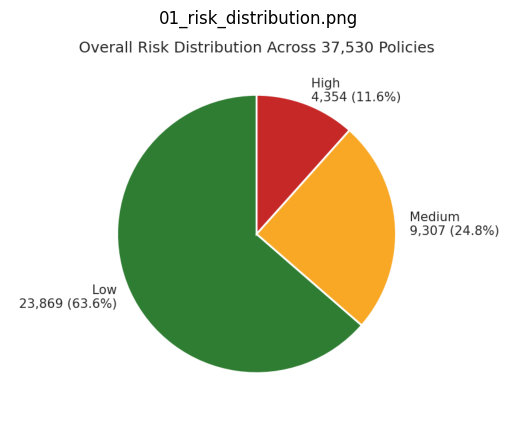

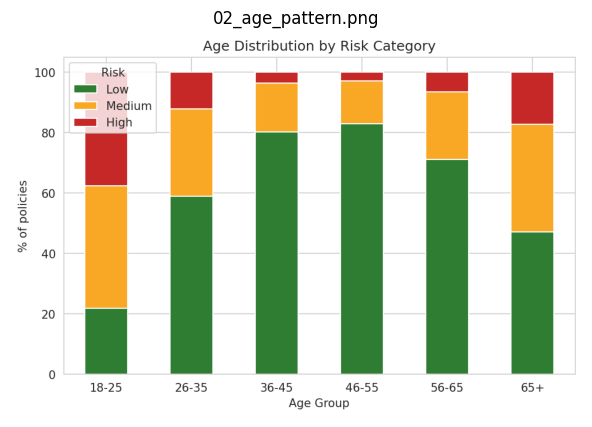

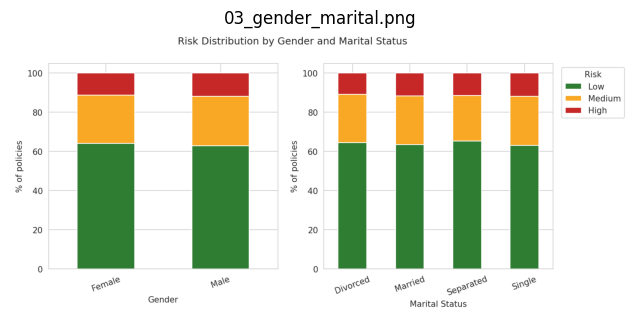

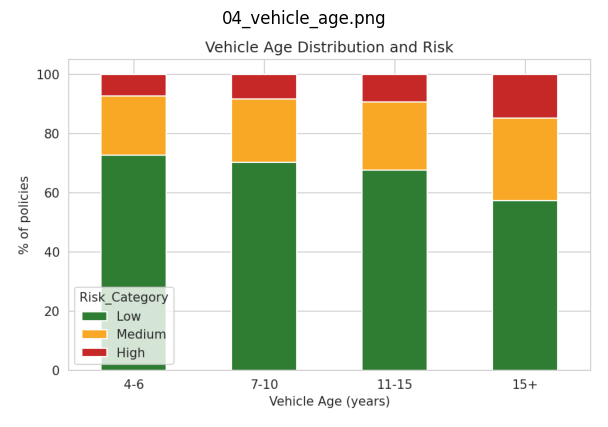

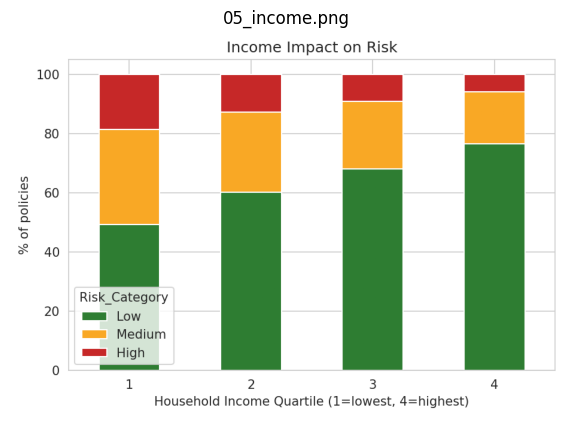

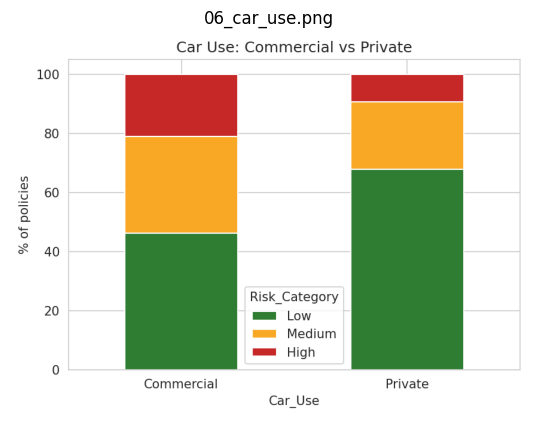

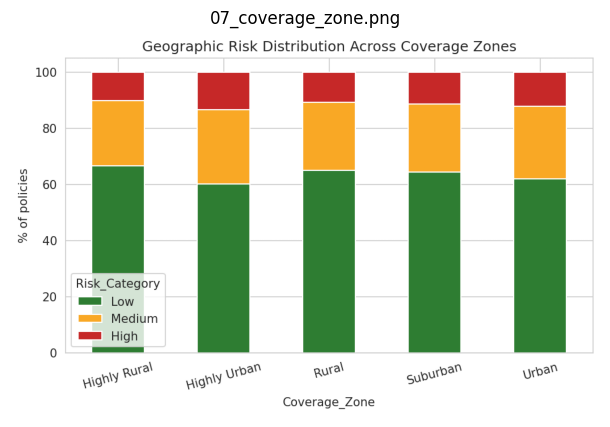

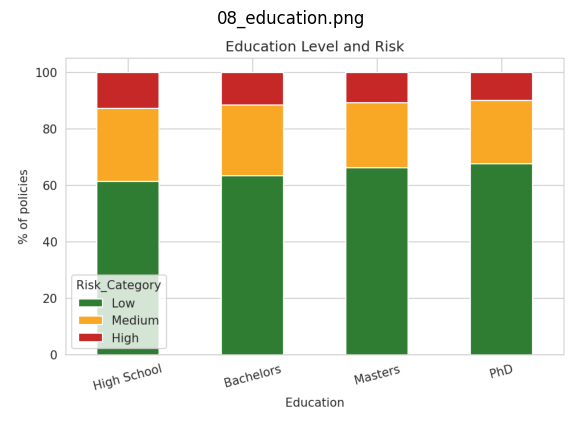

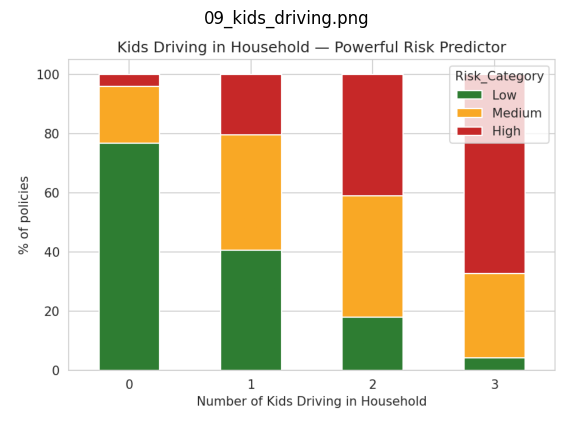

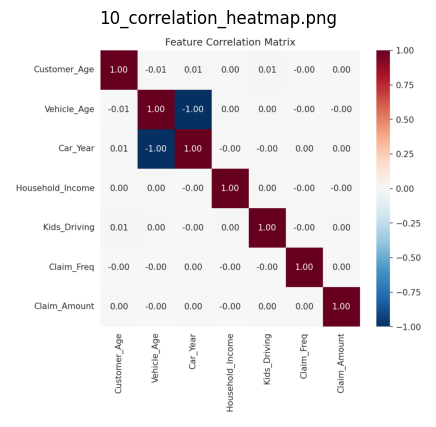

In [5]:
from src import config
import matplotlib.image as mpimg

fig_files = [
    "01_risk_distribution.png", "02_age_pattern.png", "03_gender_marital.png",
    "04_vehicle_age.png", "05_income.png", "06_car_use.png",
    "07_coverage_zone.png", "08_education.png", "09_kids_driving.png",
    "10_correlation_heatmap.png",
]
for fname in fig_files:
    path = config.FIGURES_DIR / fname
    if path.exists():
        plt.figure(figsize=(8, 5))
        plt.imshow(mpimg.imread(path))
        plt.axis('off')
        plt.title(fname)
        plt.show()
    else:
        print(f"Missing (run `python -m src.eda` first): {fname}")


## Key observations

Risk distribution is heavily skewed toward low-risk (roughly 63% low, a
quarter medium, a little over a tenth high), which looks like a realistic
insurance book of business and is the target balance the risk-labeling
rules in `src/risk_labeling.py` are calibrated to reproduce.

Customer age shows the expected U-shape: risk is highest for young
drivers, lowest around mid-life, and creeps back up for older drivers.
Kids driving and household income are strong, consistent signals too.

Claim Freq and Claim Amount, the two real data columns used later for the
claims models, show very little relationship with any demographic feature
(see the correlation heatmap). That gets explored, and reported honestly,
in notebook 04.
